## 1. Exploración inicial de datos

Carga del dataset y descripción general: dimensiones, tipos de dato y estructura base.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel(r'C:\Users\denny\OneDrive\Escritorio\Henry\M5_Henry\Base_de_datos.xlsx')

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.info()

Dimensiones: 10763 filas x 23 columnas
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64

### Caracterización de variables

| Tipo | Variables |
|---|---|
| **Numéricas continuas** | capital_prestado, salario_cliente, cuota_pactada, puntaje, puntaje_datacredito, saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor, promedio_ingresos_datacredito |
| **Numéricas discretas** | plazo_meses, edad_cliente, cant_creditosvigentes, huella_consulta, total_otros_prestamos, creditos_sectorFinanciero, creditos_sectorCooperativo, creditos_sectorReal |
| **Categórica nominal** | tipo_credito (código, no magnitud), tipo_laboral |
| **Categórica ordinal** | tendencia_ingresos (Decreciente < Estable < Creciente) |
| **Categórica dicotómica** | Pago_atiempo (variable objetivo: 1 = pagó a tiempo, 0 = no pagó a tiempo) |
| **Fecha** | fecha_prestamo |

`tipo_credito` viene como `int64` pero es nominal — se debe castear a `category` para que no se interprete como magnitud.

### Revisión y unificación de nulos

Se detectaron nulos "disfrazados": valores fuera del dominio válido de la variable.
- `tendencia_ingresos`: solo admite {Creciente, Estable, Decreciente}; aparecen valores numéricos residuales que no pertenecen a esta categoría → se convierten a NaN.
- `tipo_credito`: aparece un valor `68` con una sola observación, fuera del rango de categorías reales (4, 6, 7, 9, 10) → se convierte a NaN.

In [2]:
# Nulos explícitos antes de limpiar
print('Nulos antes de unificar:')
print(df.isnull().sum()[df.isnull().sum()>0])

# Unificar tendencia_ingreso: solo 3 categorías válidas
categorias_validas= ['Creciente','Estable','Decreciente']
df.loc[~df['tendencia_ingresos'].isin(categorias_validas), 'tendencia_ingresos'] = np.nan

# Unificar tipo_credito: valor anómalo 68 -> NaN
df.loc[df['tipo_credito'] == 68, 'tipo_credito'] = np.nan

print("\nNulos DESPUÉS de unificar:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos antes de unificar:
puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
dtype: int64

Nulos DESPUÉS de unificar:
tipo_credito                        1
puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2990
dtype: int64


### Corrección de tipos de dato

Se castea cada columna a su tipo correcto según la caracterización anterior.

In [5]:
# Categóricas nominales
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')

# Categóricas ordinal (con orden explícito)
from pandas.api.types import CategoricalDtype
orden_tendencia= CategoricalDtype(categories=['Decreciente','Estable','Creciente'], ordered=True)
df['tendencia_ingresos'] = df['tendencia_ingresos'].astype(orden_tendencia)

# Dicotómica / target 
df['Pago_atiempo'] = df['Pago_atiempo'].astype('category')  

# Fecha ya viene bien tipada (datetime64) desde el read_excel, se confirma
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'])
df.dtypes

tipo_credito                           category
fecha_prestamo                   datetime64[us]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

### Eliminación de variables irrelevantes

*(pendiente de definir tras el análisis multivariable — ninguna columna se elimina en esta etapa inicial, ya que todas aportan información potencialmente relevante para predecir `Pago_atiempo`)*

## 2. Análisis univariable — Variables numéricas

Describe estadístico ampliado (tendencia central, dispersión y forma) + histograma y boxplot por variable.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

num_cols = ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
            'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito',
            'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total',
            'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero',
            'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

# Describe base
desc= df[num_cols].describe().T

# Medidas de formas adicionales (ignorando NaN)
desc['skewness'] = df[num_cols].apply(lambda x: skew(x.dropna()))
desc['kurtosis'] = df[num_cols].apply(lambda x: kurtosis(x.dropna()))
desc['rango'] = desc['max'] - desc['min']
desc['IQR'] = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)

desc

Matplotlib is building the font cache; this may take a moment.


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,rango,IQR
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07,3.723365,35.301130,4.108415e+07,1860009.00
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01,2.459348,7.775949,8.800000e+01,6.00
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02,1.934129,7.864723,1.040000e+02,20.00
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10,43.770563,2210.202459,2.200000e+10,2875808.00
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09,38.458525,1718.481718,6.787675e+09,1500000.00
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06,3.792772,26.637820,3.792808e+06,166792.00
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01,-4.864929,24.069268,1.332378e+02,0.00
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02,-5.643726,39.418912,1.006000e+03,68.00
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01,1.797487,8.618783,6.200000e+01,5.00
huella_consulta,10763.0,4.228561e+00,3.064683e+00,0.00000,2.000000e+00,4.000000e+00,6.000000e+00,2.900000e+01,1.486895,3.996569,2.900000e+01,4.00


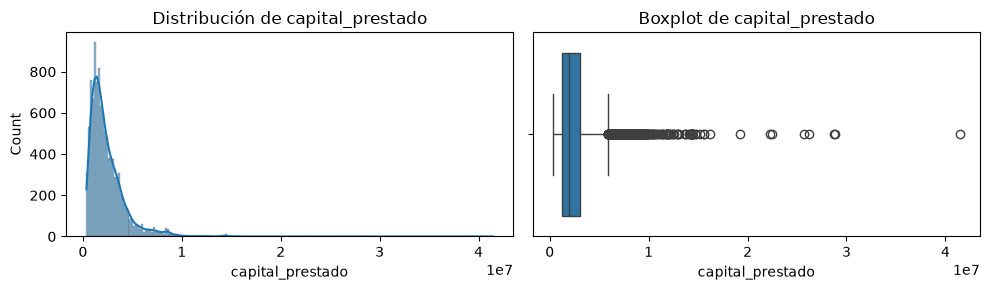

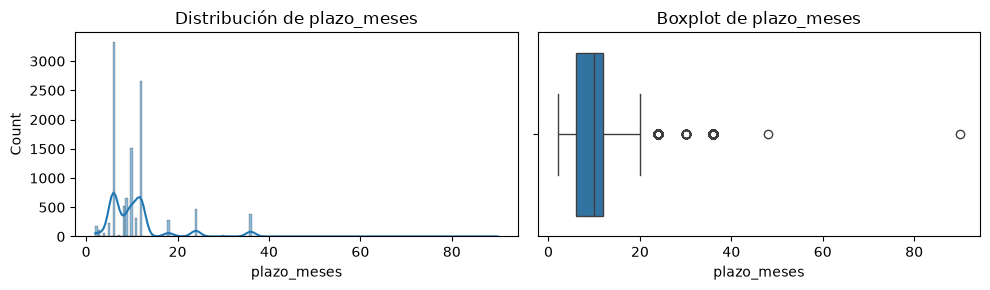

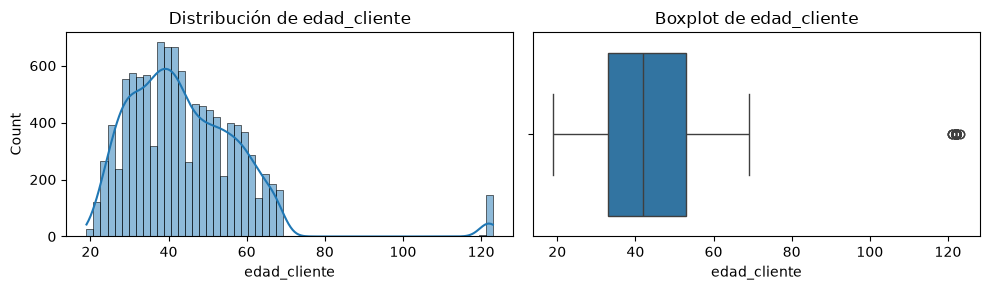

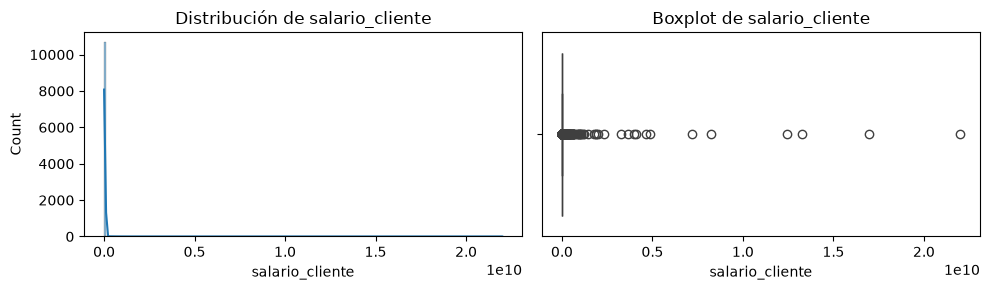

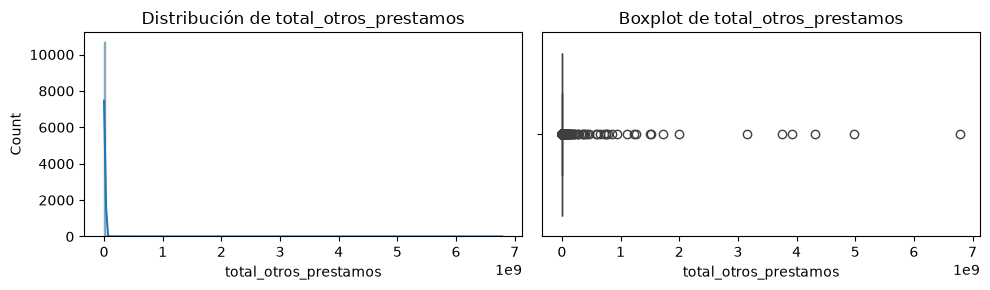

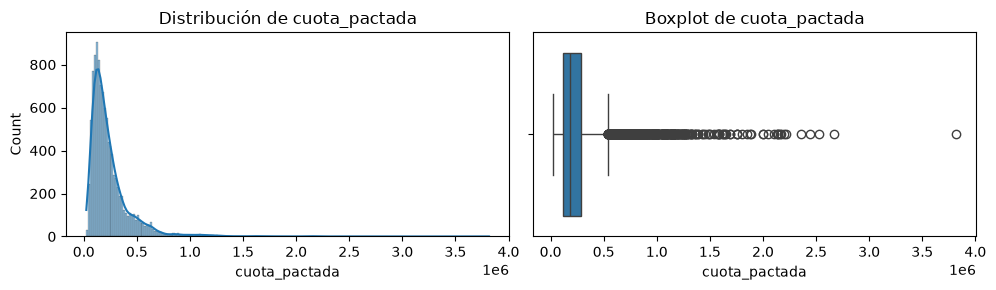

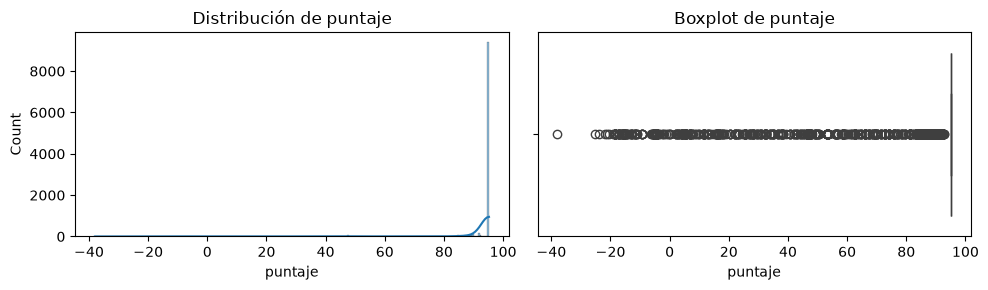

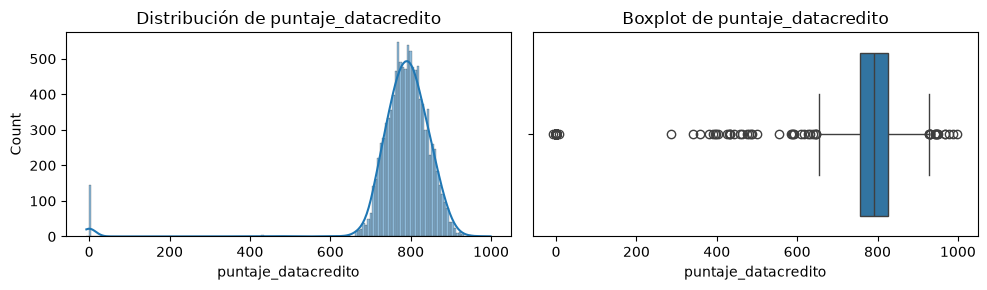

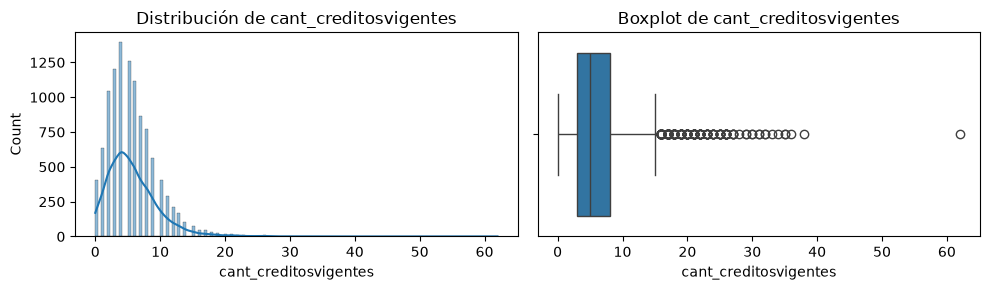

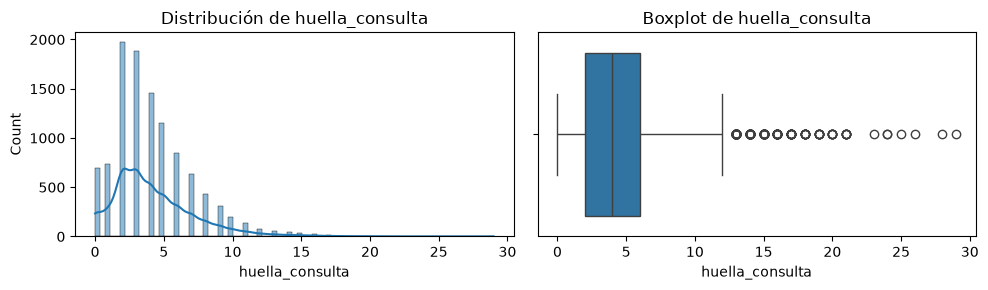

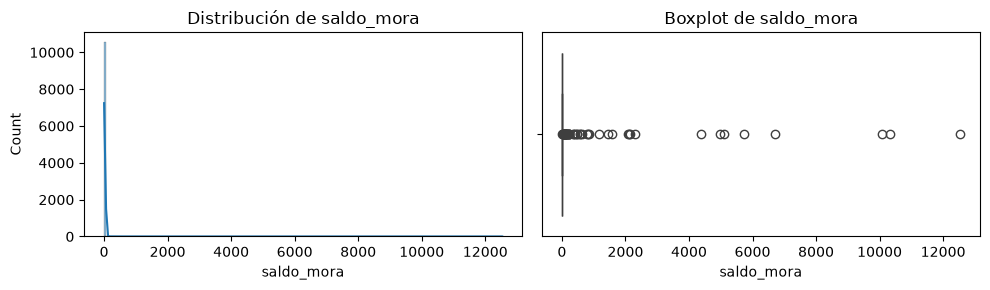

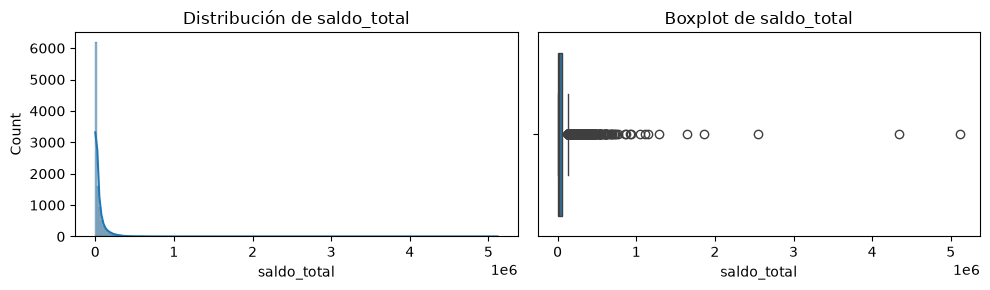

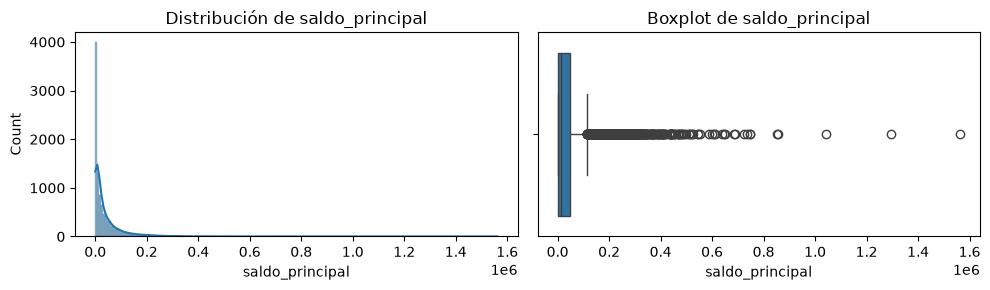

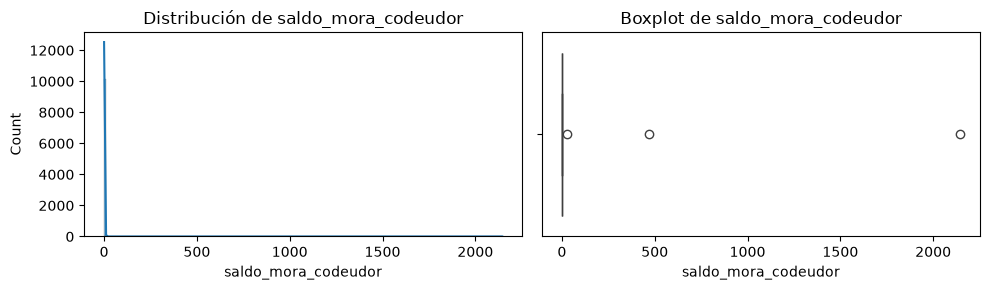

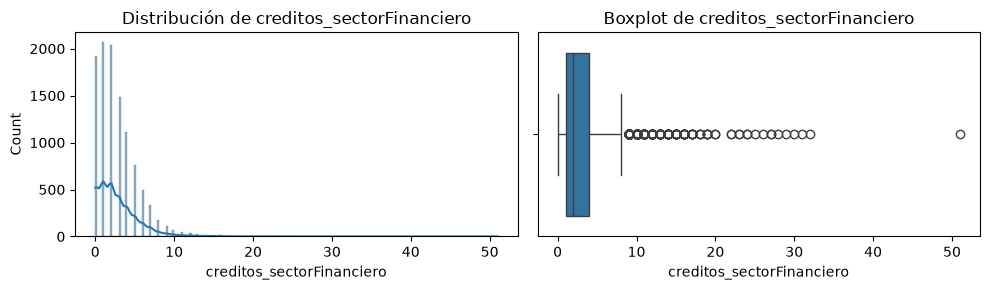

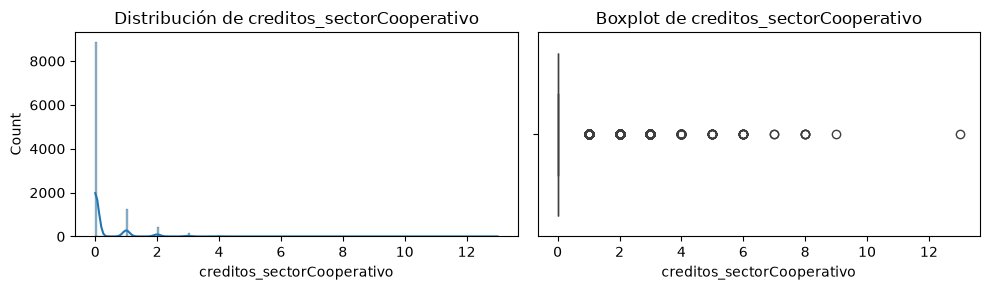

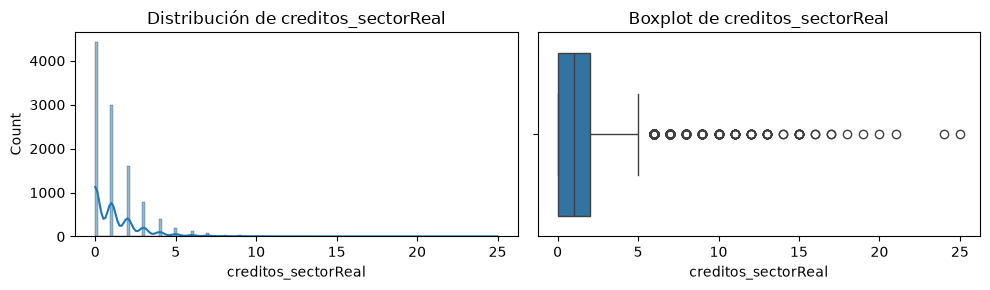

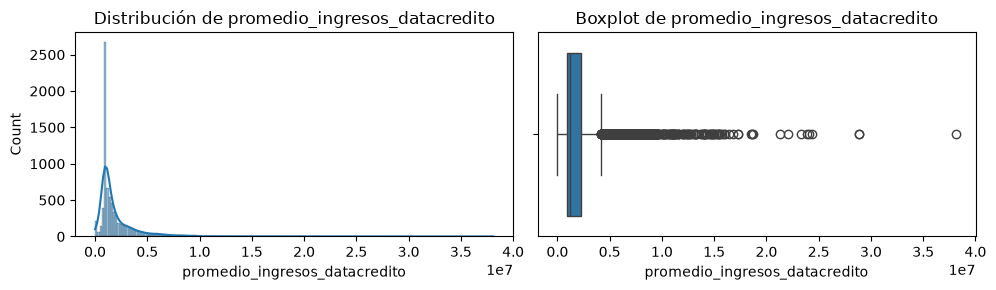

In [7]:
# Histogramas y boxplots por variable numérica
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()

### Interpretación — variables numéricas

- `saldo_mora` y `saldo_mora_codeudor`: la gran mayoría de los clientes tiene saldo en 0 (no están en mora); los valores distintos de 0 aparecen como outliers en el boxplot. Dado que la clase objetivo (`Pago_atiempo`) también está desbalanceada hacia el pago a tiempo, esta variable es candidata fuerte a tener relación directa con el target — se profundiza en el análisis bivariable.
- `capital_prestado`: asimetría positiva moderada, cola derecha corta — hay préstamos de monto alto pero no tan extremos como en otras variables monetarias.
- `salario_cliente`: fuerte concentración en valores bajos/medios con cola larga a la derecha, similar al patrón de `saldo_mora` — pocos clientes con salarios muy altos estiran la distribución.
- Ambas variables (`capital_prestado`, `salario_cliente`) presentan cantidad considerable de outliers en el boxplot — se documenta como hallazgo para la etapa de reglas de validación/transformación (posible tratamiento con capping o transformación logarítmica en etapas posteriores del pipeline).

## 3. Análisis univariable — Variables categóricas

Conteo de frecuencias (`value_counts`) y visualización (`countplot`) para cada variable categórica.

--- tipo_credito ---
tipo_credito
 4.0     7747
 9.0     2876
 10.0     116
 6.0       21
 7.0        2
NaN         1
Name: count, dtype: int64
% nulos: 0.01%



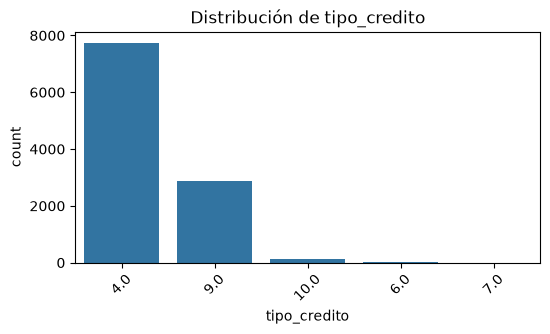

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64
% nulos: 0.00%



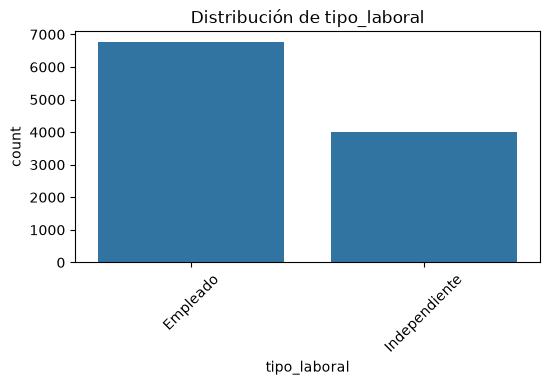

--- tendencia_ingresos ---
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64
% nulos: 27.78%



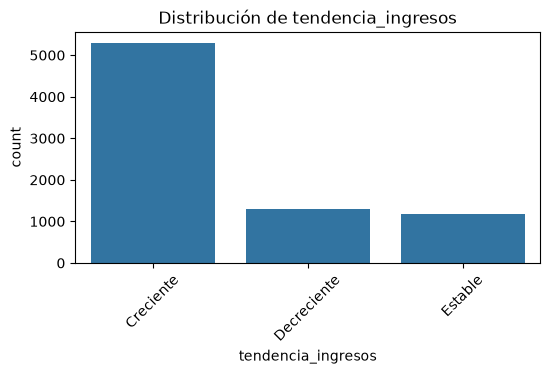

--- Pago_atiempo ---
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64
% nulos: 0.00%



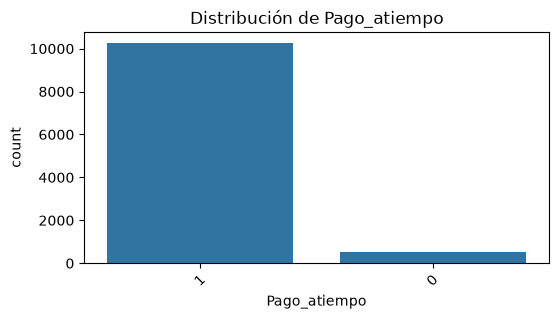

In [8]:
cat_cols = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print(f"% nulos: {df[col].isnull().mean()*100:.2f}%\n")

    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.show()

### Interpretación — variables categóricas

- `Pago_atiempo` (target): fuertemente desbalanceada (~95% clase 1 vs ~5% clase 0). El accuracy simple no es una métrica confiable para evaluar el modelo — se debe priorizar Recall/Precision/PR-AUC en etapas posteriores.
- `tipo_credito`: dominado por 2 categorías (4 y 9, >98% de los casos); las categorías 6 y 7 tienen muy pocas observaciones (21 y 2 respectivamente) — candidatas a agruparse en "Otros" antes del modelado.
- *(completar con tu lectura de `tipo_laboral`)*

## 4. Análisis bivariable — Variables vs. Pago_atiempo

Se cruza cada variable con la variable objetivo para identificar patrones relacionados con el pago a tiempo.

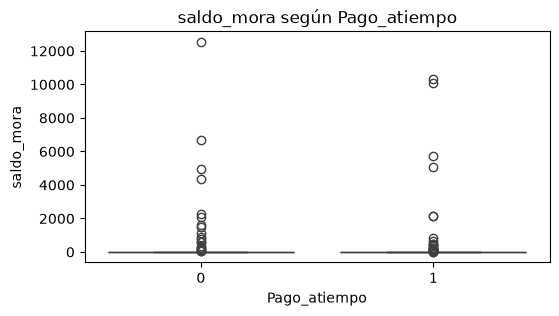

Pago_atiempo
0    0.0
1    0.0
Name: saldo_mora, dtype: float64



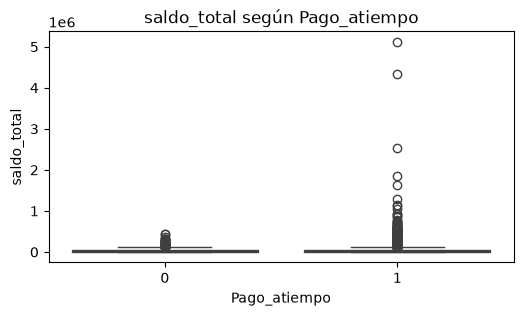

Pago_atiempo
0    14518.5
1    16308.0
Name: saldo_total, dtype: float64



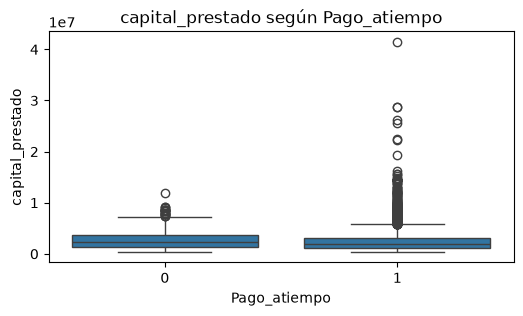

Pago_atiempo
0    2268000.0
1    1908446.4
Name: capital_prestado, dtype: float64



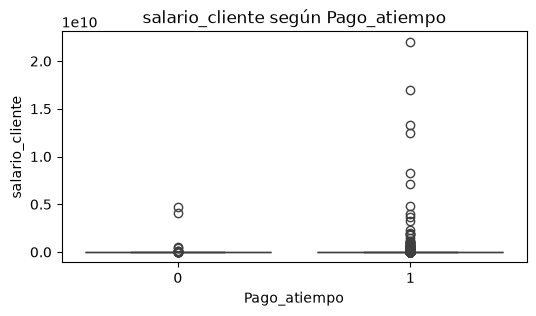

Pago_atiempo
0    3000000.0
1    3000000.0
Name: salario_cliente, dtype: float64



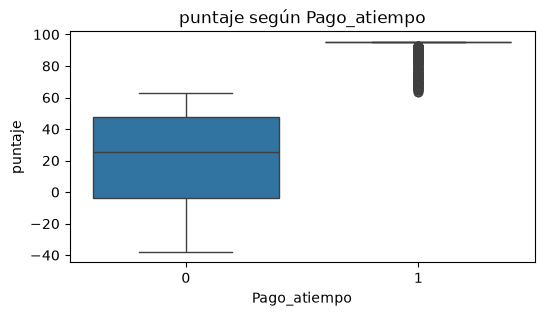

Pago_atiempo
0    25.419455
1    95.227787
Name: puntaje, dtype: float64



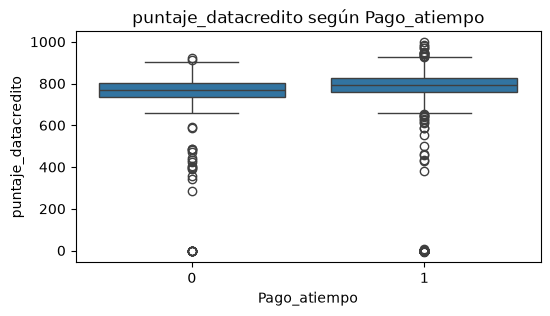

Pago_atiempo
0    768.0
1    792.0
Name: puntaje_datacredito, dtype: float64



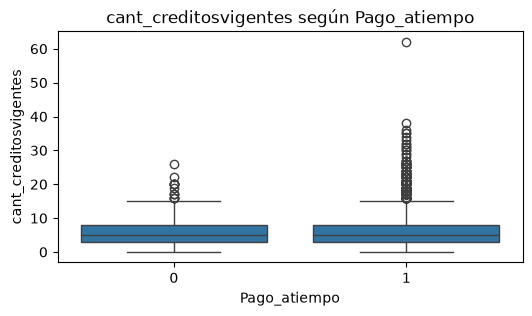

Pago_atiempo
0    5.0
1    5.0
Name: cant_creditosvigentes, dtype: float64



In [12]:
# Numéricas vs Pago_atiempo
num_relevantes = ['saldo_mora', 'saldo_total', 'capital_prestado', 'salario_cliente',
                   'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes']

for col in num_relevantes:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=df, x='Pago_atiempo', y=col)
    plt.title(f'{col} según Pago_atiempo')
    plt.show()

    print(df.groupby('Pago_atiempo')[col].median())
    print()

### Interpretación — análisis bivariable

- `saldo_mora`: la mediana no discrimina entre grupos (0 en ambos, por la alta concentración de ceros). Al binarizar como `tiene_mora`, se observa que el 3.9% de los clientes que NO pagaron a tiempo tienen mora activa, frente a solo 0.3% de los que sí pagaron a tiempo — una diferencia de ~13x. `tiene_mora` es candidata a variable derivada útil para el modelo (ver sección de atributos adicionales).

In [14]:
df['tiene_mora'] = (df['saldo_mora'] > 0).astype('category')
tabla_mora = pd.crosstab(df['tiene_mora'], df['Pago_atiempo'], normalize='columns') * 100
print(tabla_mora.round(1))

Pago_atiempo     0     1
tiene_mora              
False         96.1  99.7
True           3.9   0.3


--- tipo_laboral vs Pago_atiempo (% por fila) ---
Pago_atiempo     0     1
tipo_laboral            
Empleado       4.3  95.7
Independiente  5.5  94.5



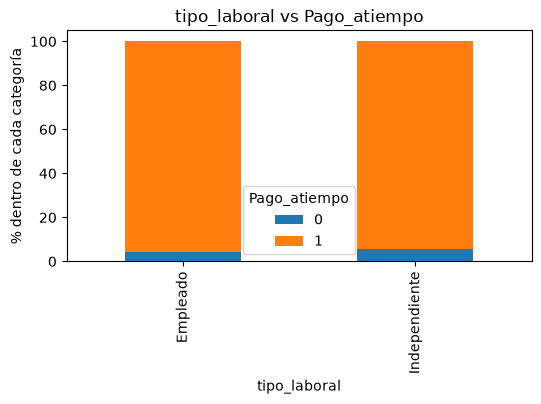

--- tipo_credito vs Pago_atiempo (% por fila) ---
Pago_atiempo     0      1
tipo_credito             
4.0            4.7   95.3
6.0           42.9   57.1
7.0            0.0  100.0
9.0            4.7   95.3
10.0           2.6   97.4



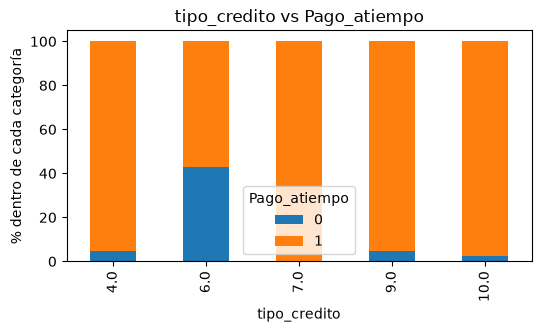

--- tendencia_ingresos vs Pago_atiempo (% por fila) ---
Pago_atiempo          0     1
tendencia_ingresos           
Decreciente         6.3  93.7
Estable             4.6  95.4
Creciente           3.9  96.1



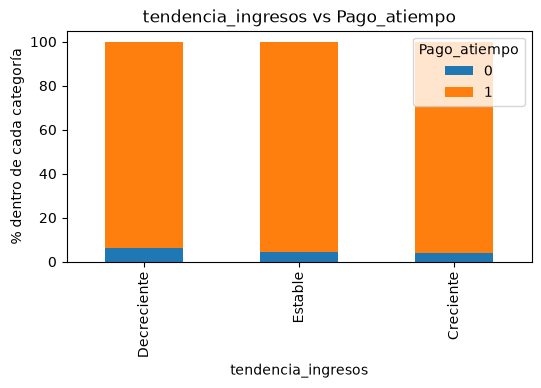

In [13]:
# categóricas vs Pago_atiempo
cat_relevantes = ['tipo_laboral', 'tipo_credito', 'tendencia_ingresos']

for col in cat_relevantes:
    tabla = pd.crosstab(df[col], df['Pago_atiempo'], normalize='index') * 100
    print(f"--- {col} vs Pago_atiempo (% por fila) ---")
    print(tabla.round(1))
    print()

    tabla.plot(kind='bar', stacked=True, figsize=(6,3))
    plt.title(f'{col} vs Pago_atiempo')
    plt.ylabel('% dentro de cada categoría')
    plt.show()

- `tendencia_ingresos`: se observa relación con `Pago_atiempo` en la dirección esperada — 6.3% de no-pago cuando la tendencia es Decreciente, vs 3.9% cuando es Creciente (~1.6x). El efecto es más moderado que el de `tiene_mora`, pero consistente con la hipótesis de negocio.

## 5. Análisis multivariable

Relación conjunta entre las variables numéricas más relevantes, y su relación con la variable objetivo.

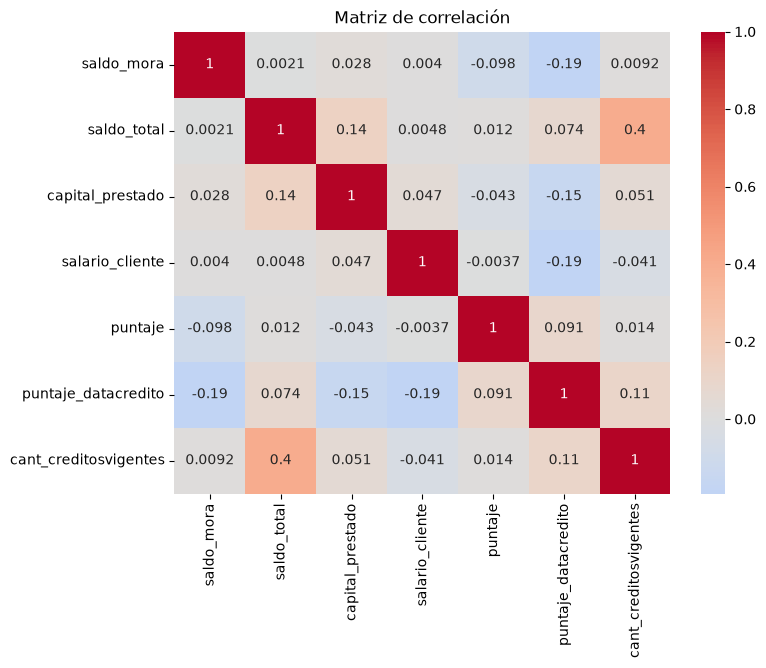

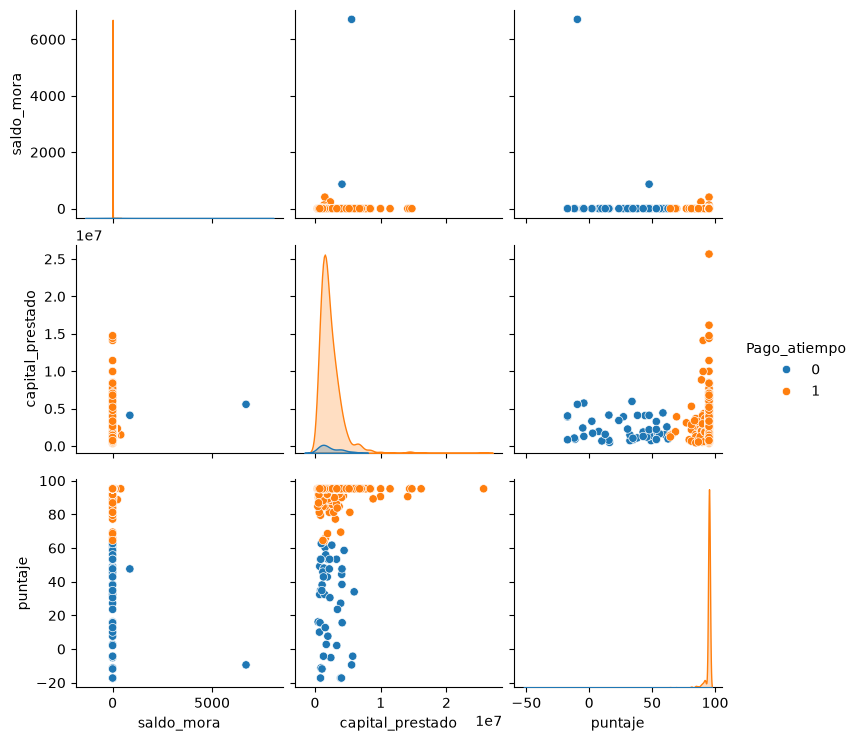

In [15]:
# Matriz de correlación
corr_cols = ['saldo_mora', 'saldo_total', 'capital_prestado', 'salario_cliente',
             'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes']

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

# Pairplot con hue por Pago_atiempo (muestra reducida por tiempo de cómputo)
sample = df.sample(1000, random_state=42)
sns.pairplot(sample, vars=['saldo_mora','capital_prestado','puntaje'], hue='Pago_atiempo')
plt.show()

### Interpretación — análisis multivariable

- Multicolinealidad baja en general (mayoría de correlaciones entre -0.19 y 0.14) — no se anticipan problemas de redundancia entre variables numéricas para el modelado.
- Correlación más alta: `saldo_total` vs `cant_creditosvigentes` (0.4, moderada) — coherente con la lógica de negocio (más créditos vigentes, más deuda acumulada).
- `puntaje` y `puntaje_datacredito` casi no correlacionan (0.091) — sugiere que miden aspectos distintos del riesgo crediticio (posiblemente un score interno vs. uno externo de central de riesgo); se recomienda no asumir que son intercambiables.

## 6. Conclusiones y reglas de validación

**Hallazgos clave:**
- `Pago_atiempo` está fuertemente desbalanceada (95%/5%) — se debe evitar accuracy como métrica única en el modelado.
- `tiene_mora` (variable derivada de `saldo_mora > 0`) muestra la relación más fuerte con el target (13x más frecuente en no-pago).
- `tendencia_ingresos` muestra relación moderada y consistente con la hipótesis de negocio.
- `tipo_credito` tiene categorías con muy pocas observaciones (6, 7) — candidatas a agruparse en "Otros".
- `tendencia_ingresos` tenía valores numéricos contaminando la columna (fuera de su dominio válido) — corregidos a NaN.

**Reglas de validación propuestas:**
- `tendencia_ingresos` solo admite {Creciente, Estable, Decreciente}.
- `tipo_credito` solo admite valores {4, 6, 7, 9, 10}.
- Variables monetarias (`capital_prestado`, `salario_cliente`, `saldo_*`) no deberían tener valores negativos.

**Atributos derivados propuestos:**
- `tiene_mora` (binaria, ya creada): `saldo_mora > 0`.
- Posible variable de "capacidad de pago": relación entre `cuota_pactada` y `salario_cliente`.